# Modelo de Ising con Campo Transverso (TFIM): ED, Trotter/Selene y VQE

**Quantathon CR 2026 -- Challenge 3**

Este notebook consolida en un solo flujo coherente los tres análisis desarrollados por
separado durante el hackathon:

1. **Diagonalización exacta (ED)** -- línea base clásica: energía del estado fundamental,
   magnetización y correlaciones en función de `h/J`.
2. **Evolución temporal Trotterizada (guppylang + Selene)** -- simulación de un circuito
   cuántico que aproxima `U(t) = e^{-iHt}` y se compara contra ED.
3. **VQE con un Hardware-Efficient Ansatz (HEA)** -- estimación variacional del estado
   fundamental, también comparada contra ED.

## Contenido

1. [Teoría: el Hamiltoniano del TFIM](#teoria)
2. [Sección A -- Diagonalización exacta (línea base clásica)](#seccion-a)
3. [Sección B -- Evolución Trotterizada con guppylang + Selene](#seccion-b)
4. [Sección C -- Análisis del error de Trotter](#seccion-c)
5. [Sección D -- VQE con Hardware-Efficient Ansatz](#seccion-d)
6. [Limitaciones honestas](#limitaciones)

**Requisitos de entorno:** las Secciones B, C y D requieren `guppylang`, `selene_sim` y
(opcionalmente, para las celdas marcadas como *Nexus/cloud*) `qnexus`. Ver `CLAUDE.md` en la
raíz del repositorio para instrucciones de instalación -- el entorno virtual `quantathon_env/`
existe pero debe poblarse con `pip install -r requirements.txt` antes de ejecutar estas
secciones.

<a id="teoria"></a>
## 1. Teoría: el Hamiltoniano del TFIM

El modelo de Ising con campo transverso (TFIM) para una cadena de `N` espines con
condiciones de frontera periódicas (PBC) está dado por

$$
H = -J \sum_{i=1}^{N} Z_i Z_{i+1} \;-\; h \sum_{i=1}^{N} X_i ,
$$

con `Z_{N+1} \equiv Z_1` (la cadena se cierra en un anillo). `J` fija la escala de energía de
interacción ferromagnética entre espines vecinos y `h` es la intensidad del campo magnético
transverso. Fijamos `J = 1` en todo el notebook y barremos la razón `h/J`.

Este modelo tiene una transición de fase cuántica en el punto crítico `h/J = 1`:

- **`h/J < 1`** (fase ferromagnética): el estado fundamental favorece el orden en `Z`,
  `⟨Z⟩` es grande en magnitud y las correlaciones `⟨Z_i Z_{i+1}⟩` son fuertemente positivas.
- **`h/J > 1`** (fase paramagnética): el campo transverso domina, el estado fundamental se
  polariza a lo largo de `X`, `⟨Z⟩ → 0` y las correlaciones `⟨Z_i Z_{i+1}⟩` decaen.
- **`h/J = 1`**: punto crítico, donde la longitud de correlación diverge (en el límite
  termodinámico `N → ∞`; para `N` finito la transición se observa suavizada).

Los observables que reportamos consistentemente en las tres secciones son:

$$
\langle Z \rangle = \frac{1}{N}\sum_i \langle Z_i \rangle, \qquad
\langle X \rangle = \frac{1}{N}\sum_i \langle X_i \rangle, \qquad
\langle Z_i Z_{i+1} \rangle_{nn} = \frac{1}{N}\sum_i \langle Z_i Z_{i+1} \rangle .

<a id="seccion-a"></a>
## 2. Sección A -- Diagonalización exacta (línea base clásica)

Construimos `H` como una matriz densa `2^N x 2^N` vía productos de Kronecker de las matrices
de Pauli, la diagonalizamos exactamente (`scipy.linalg.eigh`) y calculamos observables sobre
el estado fundamental (diagrama de fases) y sobre la evolución temporal exacta (referencia
para comparar contra el circuito Trotterizado en la Sección B).

Esta es la implementación de línea base clásica del proyecto (adaptada de
`Simulacion Ed.ipynb`); todas las secciones posteriores reutilizan `build_tfim_hamiltonian`,
`compute_magnetization` y `compute_nearest_neighbor_correlation` en vez de reimplementarlas,
para mantener una única fuente de verdad para la física clásica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.sparse import csr_matrix, kron, eye
from scipy.sparse.linalg import eigsh
import time
from typing import Tuple, List, Optional

In [8]:
# -----------------------------------------------------------------------
# A.1 Operadores de Pauli y construcción del Hamiltoniano
# -----------------------------------------------------------------------

def pauli_matrices() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    '''Devuelve las matrices de Pauli I, X, Y, Z.'''
    I = np.array([[1, 0], [0, 1]], dtype=complex)
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    return I, X, Y, Z


def build_single_operator(op: np.ndarray, qubit: int, n_qubits: int) -> np.ndarray:
    '''Construye un operador que actua como 'op' en 'qubit' e identidad en los demas.'''
    I, _, _, _ = pauli_matrices()
    operators = [I] * n_qubits
    operators[qubit] = op
    result = operators[0]
    for op_i in operators[1:]:
        result = np.kron(result, op_i)
    return result


def build_two_qubit_operator(op1: np.ndarray, op2: np.ndarray,
                              qubit1: int, qubit2: int, n_qubits: int) -> np.ndarray:
    '''Construye un operador que actua como op1 en qubit1 y op2 en qubit2.'''
    I, _, _, _ = pauli_matrices()
    operators = [I] * n_qubits
    operators[qubit1] = op1
    operators[qubit2] = op2
    result = operators[0]
    for op_i in operators[1:]:
        result = np.kron(result, op_i)
    return result


def build_tfim_hamiltonian(n_qubits: int, J: float = 1.0, h: float = 1.0,
                            periodic: bool = True, use_sparse: bool = False, eps: float = 0.00):
    '''
    H = -J * sum_i Z_i Z_{i+1} - h * sum_i X_i

    periodic=True cierra la cadena en un anillo (bond N-1 <-> 0), consistente con el
    circuito de Trotter de la Seccion B, que incluye ese mismo bond periodico.
    '''
    _, X, _, Z = pauli_matrices()
    dim = 2 ** n_qubits

    if use_sparse:
        from scipy.sparse import lil_matrix
        H = lil_matrix((dim, dim), dtype=complex)
    else:
        H = np.zeros((dim, dim), dtype=complex)

    bonds = n_qubits if periodic else n_qubits - 1
    for i in range(bonds):
        j = (i + 1) % n_qubits
        ZZ_op = build_two_qubit_operator(Z, Z, i, j, n_qubits)
        H += -J * ZZ_op

    for i in range(n_qubits):
        X_op = build_single_operator(X, i, n_qubits)
        H += -h * X_op
    Z_op = build_single_operator(Z, i, n_qubits)
    H += -eps * Z_op
    
    return H.tocsr() if use_sparse else H

In [9]:
# -----------------------------------------------------------------------
# A.2 Observables
# -----------------------------------------------------------------------

def compute_magnetization(state: np.ndarray, n_qubits: int, axis: str = 'Z') -> float:
    '''Magnetizacion promedio (1/N) sum_i <op_i> a lo largo de 'Z' o 'X'.'''
    I, X, _, Z = pauli_matrices()
    op = {'Z': Z, 'X': X}[axis]

    total_op = np.zeros((2 ** n_qubits, 2 ** n_qubits), dtype=complex)
    for i in range(n_qubits):
        total_op += build_single_operator(op, i, n_qubits)
    total_op /= n_qubits

    if state.ndim == 2:  # matriz de densidad
        return np.trace(total_op @ state).real
    return (state.conj().T @ total_op @ state).real


def compute_correlation(state: np.ndarray, n_qubits: int, i: int, j: int) -> float:
    '''<Z_i Z_j> para un estado dado.'''
    _, _, _, Z = pauli_matrices()
    op = build_single_operator(Z, i, n_qubits) @ build_single_operator(Z, j, n_qubits)
    if state.ndim == 2:
        return np.trace(op @ state).real
    return (state.conj().T @ op @ state).real


def compute_nearest_neighbor_correlation(state: np.ndarray, n_qubits: int,
                                          periodic: bool = True) -> float:
    '''Promedio de <Z_i Z_{i+1}> sobre todos los bonds vecinos-cercanos.'''
    bonds = n_qubits if periodic else n_qubits - 1
    total_corr = 0.0
    for i in range(bonds):
        j = (i + 1) % n_qubits
        total_corr += compute_correlation(state, n_qubits, i, j)
    return total_corr / bonds

### A.3 Diagrama de fases (barrido de `h/J`, estado fundamental)

Diagonalizamos `H` para una malla de valores de `h` y extraemos el estado fundamental
(autovector de menor energía) en cada punto. Esto reproduce la transición de fase cuántica
alrededor de `h/J = 1`.

In [12]:
def analyze_tfim(n_qubits: int, h_values: Optional[List[float]] = None,
                  J: float = 1.0, periodic: bool = True) -> dict:
    '''Barrido de h: energia del estado fundamental y observables asociados.'''
    if h_values is None:
        h_values = np.linspace(0.0, 3.0, 31)

    results = {'h_values': h_values, 'energies': [], 'magnetization_Z': [],
               'magnetization_X': [], 'correlation_NN': [], 'times': []}

    eps = 0.00 # agrega una pequeña perturbacion al sistema para que el observable <Z> no colapse a 0 para h> 0 
    for h in h_values:
        start_time = time.time()
        H = build_tfim_hamiltonian(n_qubits, J, h, periodic=periodic, eps=eps)
        eigenvalues, eigenvectors = eigh(H)
        ground_state = eigenvectors[:, 0]
        energy = eigenvalues[0]

        mz = compute_magnetization(ground_state, n_qubits, 'Z')
        mx = compute_magnetization(ground_state, n_qubits, 'X')
        corr = compute_nearest_neighbor_correlation(ground_state, n_qubits, periodic=periodic)

        results['energies'].append(energy)
        results['magnetization_Z'].append(mz)
        results['magnetization_X'].append(mx)
        results['correlation_NN'].append(corr)
        results['times'].append(time.time() - start_time)

    return results


def plot_phase_diagram(results: dict, n_qubits: int, save_path: Optional[str] = None):
    '''Grafica el diagrama de fases: magnetizacion/correlacion/energia vs h/J.'''
    h_values = results['h_values']
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].plot(h_values, results['magnetization_Z'], 'b-', linewidth=2, label=f'N={n_qubits}')
    axes[0, 0].axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='h/J = 1')
    axes[0, 0].set_xlabel(r'$h/J$'); axes[0, 0].set_ylabel(r'$\langle Z \rangle$')
    axes[0, 0].set_title('Magnetizacion longitudinal'); axes[0, 0].grid(alpha=0.3); axes[0, 0].legend()

    axes[0, 1].plot(h_values, results['magnetization_X'], 'r-', linewidth=2)
    axes[0, 1].axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
    axes[0, 1].set_xlabel(r'$h/J$'); axes[0, 1].set_ylabel(r'$\langle X \rangle$')
    axes[0, 1].set_title('Magnetizacion transversa'); axes[0, 1].grid(alpha=0.3)

    axes[1, 0].plot(h_values, results['correlation_NN'], 'g-', linewidth=2)
    axes[1, 0].axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
    axes[1, 0].set_xlabel(r'$h/J$'); axes[1, 0].set_ylabel(r'$\langle Z_i Z_{i+1} \rangle$')
    axes[1, 0].set_title('Correlacion vecinos mas cercanos'); axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(h_values, results['energies'], color='purple', linewidth=2)
    axes[1, 1].axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel(r'$h/J$'); axes[1, 1].set_ylabel(r'$E_0$')
    axes[1, 1].set_title('Energia del estado fundamental'); axes[1, 1].grid(alpha=0.3)

    plt.suptitle(f'TFIM -- Diagonalizacion exacta (N={n_qubits}, PBC)', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

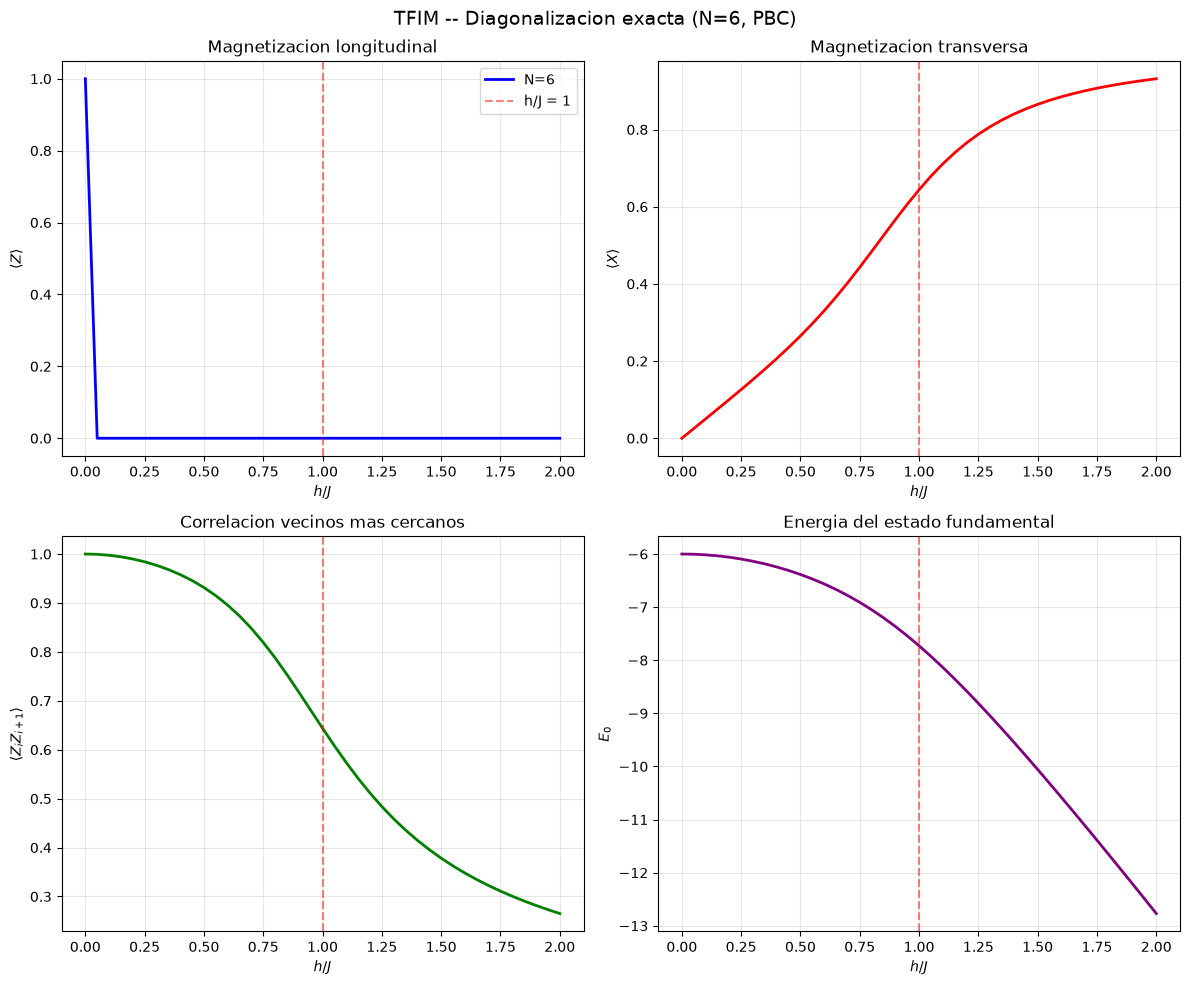

In [13]:
N_QUBITS = 6   # mismo N usado en las Secciones B y D, para que las comparaciones sean directas
J = 1.0

phase_diagram_results = analyze_tfim(N_QUBITS, h_values=np.linspace(0.0, 2.0, 41), J=J, periodic=True)
plot_phase_diagram(phase_diagram_results, N_QUBITS, save_path='tfim_phase_diagram.png')

### A.4 Evolución temporal exacta (referencia para la Sección B)

Dado el Hamiltoniano (tiempo-independiente) para un `h/J` fijo, propagamos un estado inicial
`|psi(0)>` usando la expansión en la base de autoestados:

$$
|\psi(t)\rangle = \sum_k e^{-iE_k t}\, |k\rangle\langle k|\psi(0)\rangle .
$$

Esta función se reutiliza en la Sección B como la referencia clásica "exacta" contra la cual
se compara el circuito Trotterizado -- así evitamos reimplementar la diagonalización dos veces
con Hamiltonianos potencialmente inconsistentes (p. ej. distintas condiciones de frontera).

In [14]:
def time_evolve_exact(n_qubits: int, J: float, h: float, psi0: np.ndarray,
                       times: np.ndarray, periodic: bool = True) -> dict:
    '''
    Evolucion temporal exacta bajo el TFIM (H tiempo-independiente), evaluada en
    'times'. Devuelve <Z>, <X> y <Z_i Z_{i+1}>_nn en cada tiempo solicitado.
    '''
    H = build_tfim_hamiltonian(n_qubits, J, h, periodic=periodic)
    eigenvalues, eigenvectors = eigh(H)
    coeffs0 = eigenvectors.conj().T @ psi0  # <k|psi(0)> para cada autoestado k

    Zs, Xs, ZZs = [], [], []
    for t in times:
        phases = np.exp(-1j * eigenvalues * t)
        psi_t = eigenvectors @ (phases * coeffs0)
        Zs.append(compute_magnetization(psi_t, n_qubits, 'Z'))
        Xs.append(compute_magnetization(psi_t, n_qubits, 'X'))
        ZZs.append(compute_nearest_neighbor_correlation(psi_t, n_qubits, periodic=periodic))

    return {'t': np.asarray(times), 'Z': np.asarray(Zs), 'X': np.asarray(Xs),
            'ZZ_nn': np.asarray(ZZs)}


def initial_state_all_up(n_qubits: int) -> np.ndarray:
    '''|000...0> -- todos los espines +1 a lo largo de Z (estado del quench).'''
    psi0 = np.zeros(2 ** n_qubits, dtype=complex)
    psi0[0] = 1.0
    return psi0

<a id="seccion-b"></a>
## 3. Sección B -- Evolución Trotterizada con guppylang + Selene

Queremos representar `U(t) = e^{-iHt}` como un circuito cuántico. Sustituyendo el
Hamiltoniano del TFIM:

$$
U = e^{-it\left(-J\sum_i Z_iZ_{i+1} - h\sum_i X_i\right)}
  = e^{\,it J \sum_i Z_i Z_{i+1}} \; e^{\,it h \sum_i X_i}
$$

**Trotter de primer orden.** Como los dos términos no conmutan, aproximamos la exponencial
del operador completo por el producto de exponenciales de cada término, repetido `n` veces
con paso `Δt = t/n`:

$$
U \approx \left( \prod_{i=1}^{N} e^{iJ\Delta t\, Z_iZ_{i+1}} \prod_{i=1}^{N} e^{ih\Delta t\, X_i} \right)^{n}
$$

El error local de este esquema (conmutador de los dos términos) es `O(Δt^2)` por paso, es
decir `O(T·Δt)` acumulado sobre toda la evolución.

**Trotter de segundo orden (Suzuki / simétrico).** Partiendo el término de campo en dos
mitades alrededor de la capa `ZZ` se cancela el término de error dominante:

$$
U \approx \left( \prod_{i=1}^{N} e^{i\frac{h\Delta t}{2} X_i}\; \prod_{i=1}^{N} e^{iJ\Delta t\, Z_iZ_{i+1}}\; \prod_{i=1}^{N} e^{i\frac{h\Delta t}{2} X_i} \right)^{n}
$$

con error local `O(Δt^3)`, es decir `O(T·Δt^2)` acumulado -- converge más rápido que el
esquema simple al refinar `Δt`. La Sección C cuantifica esta diferencia empíricamente.

**De la exponencial de Pauli a compuertas.** Usamos las identidades

$$
e^{i\theta\, Z_i \otimes Z_{i+1}} \;=\; \text{CX} \cdot R_Z(-2\theta) \cdot \text{CX}
\qquad\text{(target = qubit }i+1\text{)}, \qquad
e^{i\theta\, X_i} \;=\; R_X(-2\theta)
$$

**Nota sobre la convención de ángulos de guppy:** el tipo `angle` de guppy se expresa en
*medias vueltas* (`angle(1.0) == π radianes`), no en radianes -- todo ángulo en radianes debe
dividirse entre `π` antes de construirse como `angle(...)`. Es una fuente recurrente de
errores de factor `π` si se pasa por alto.

Las compuertas se ejecutan en el emulador **Selene** de Quantinuum (`selene_sim.build(...)`
+ simulador `Quest()`), que actúa como sustituto de hardware Quantinuum real.

In [15]:
import math
import numpy as np

from guppylang import guppy
from guppylang.std.builtins import array, owned, result, comptime
from guppylang.std.quantum import qubit, h, cx, rx, rz, measure_array
from guppylang.std.angles import angle, pi
from guppylang.defs import GuppyFunctionDefinition
from hugr.qsystem.result import QsysResult

from selene_sim import build, Quest

In [16]:
# -----------------------------------------------------------------------
# B.1 Parametros fisicos y del circuito (tamano de paso documentado)
# -----------------------------------------------------------------------
N = N_QUBITS           # numero de qubits -- debe coincidir con la Seccion A (dim = 2^N)
                        # y con la Seccion D. La simulacion de vector de estado en Selene
                        # escala como 2^N, mantener N pequeno (<=8-10).
# J se reutiliza de la Seccion A (J = 1.0)

T_MAX = 15.0            # tiempo total de evolucion (unidades de 1/J)
N_STEPS = 150           # numero de pasos de Trotter para llegar a T_MAX
DT = T_MAX / N_STEPS    # <-- tamano de paso de Trotter: Delta t = T_MAX / N_STEPS
N_SHOTS = 2000          # shots por circuito medido

print(f"N={N}  T_MAX={T_MAX}  N_STEPS={N_STEPS}  DT={DT:.4f}  N_SHOTS={N_SHOTS}")

N=6  T_MAX=15.0  N_STEPS=150  DT=0.1000  N_SHOTS=2000


In [17]:
# -----------------------------------------------------------------------
# B.2 Un paso de Trotter, primer orden (ZZ completo, luego X completo)
# -----------------------------------------------------------------------
@guppy.comptime
def simple_trotter_step(qs: array[qubit, comptime(N)], dt: float, h_field: float) -> None:
    theta_zz = angle(-2.0 * comptime(J) * dt / math.pi)
    for i in range(N - 1):
        cx(qs[i], qs[i + 1])
        rz(qs[i + 1], theta_zz)
        cx(qs[i], qs[i + 1])
    # bond periodico (sitio N-1 <-> sitio 0), cierra el anillo
    cx(qs[N - 1], qs[0])
    rz(qs[0], theta_zz)
    cx(qs[N - 1], qs[0])

    theta_x = angle(-2.0 * h_field * dt / math.pi)
    for i in range(N):
        rx(qs[i], theta_x)


# -----------------------------------------------------------------------
# B.3 Un paso de Trotter, segundo orden (Suzuki: X/2, ZZ, X/2)
# -----------------------------------------------------------------------
@guppy.comptime
def suzuki_trotter_step(qs: array[qubit, comptime(N)], dt: float, h_field: float) -> None:
    theta_x_half = angle(-1.0 * h_field * dt / math.pi)
    for i in range(N):
        rx(qs[i], theta_x_half)

    theta_zz = angle(-2.0 * comptime(J) * dt / math.pi)
    for i in range(N - 1):
        cx(qs[i], qs[i + 1])
        rz(qs[i + 1], theta_zz)
        cx(qs[i], qs[i + 1])
    cx(qs[N - 1], qs[0])
    rz(qs[0], theta_zz)
    cx(qs[N - 1], qs[0])

    for i in range(N):
        rx(qs[i], theta_x_half)

### B.4 Circuito completo, ejecución local en Selene y estimadores de observables

`make_circuit` compone `n_steps` pasos de Trotter y mide en la base `Z` o, si
`basis_x=True`, rota cada qubit con `H` antes de medir (para estimar `<X>`). Como los
entry-points de guppy deben ser de cero argumentos, los parámetros de tiempo se "hornean"
como constantes de clausura y el circuito se recompila en cada llamada -- el mismo patrón
usado en la Sección D para el ansatz de VQE.

In [18]:
def make_circuit(n_steps: int, basis_x: bool, h_field: float,
                  trotter_step=suzuki_trotter_step) -> GuppyFunctionDefinition:

    @guppy.comptime
    def circuit() -> None:
        qs = array(qubit() for _ in range(comptime(N)))
        for _ in range(comptime(n_steps)):
            trotter_step(qs, comptime(DT), comptime(h_field))
        if comptime(basis_x):
            for i in range(comptime(N)):
                h(qs[i])
        bits = measure_array(qs)
        result("bits", bits)

    return circuit


def run_circuit(n_steps: int, basis_x: bool, h_field: float,
                 trotter_step=suzuki_trotter_step, shots: int = N_SHOTS) -> np.ndarray:
    '''Ejecuta un circuito en el simulador local de Selene (Quest); retorna bits crudos.'''
    circuit = make_circuit(n_steps, basis_x, h_field, trotter_step)
    compiled = circuit.compile_function()
    runner = build(compiled)
    sim_result = QsysResult(runner.run_shots(simulator=Quest(), n_qubits=N, n_shots=shots))
    all_bits = [shot.as_dict()["bits"] for shot in sim_result]
    return np.array(all_bits)  # shape (shots, N), valores en {0, 1}


def z_expectation_from_bits(bits: np.ndarray) -> float:
    '''bits: (shots, N) de 0/1. <Z> promedio sobre qubits y shots.'''
    spins = 1 - 2 * bits  # 0 -> +1, 1 -> -1
    return spins.mean()


def zz_expectation_from_bits(bits: np.ndarray, nn_only: bool = True) -> float:
    spins = 1 - 2 * bits
    shots, n = spins.shape
    pairs = [(i, (i + 1) % n) for i in range(n)] if nn_only else \
            [(i, j) for i in range(n) for j in range(i + 1, n)]
    total = sum((spins[:, i] * spins[:, j]).mean() for i, j in pairs)
    return total / len(pairs)


def quantum_dynamics_scan(step_counts, h_field: float, trotter_step=suzuki_trotter_step,
                           shots: int = N_SHOTS) -> dict:
    '''Barre step_counts, ejecuta Z-basis y X-basis en cada uno, reconstruye <Z>,<X>,<ZZ>_nn.'''
    times, Z_vals, X_vals, ZZ_nn_vals = [], [], [], []
    for n_steps in step_counts:
        bits_z = run_circuit(n_steps, basis_x=False, h_field=h_field,
                              trotter_step=trotter_step, shots=shots)
        bits_x = run_circuit(n_steps, basis_x=True, h_field=h_field,
                              trotter_step=trotter_step, shots=shots)

        times.append(n_steps * DT)
        Z_vals.append(z_expectation_from_bits(bits_z))
        X_vals.append(z_expectation_from_bits(bits_x))
        ZZ_nn_vals.append(zz_expectation_from_bits(bits_z, nn_only=True))

    return {"t": np.array(times), "Z": np.array(Z_vals), "X": np.array(X_vals),
            "ZZ_nn": np.array(ZZ_nn_vals)}

### B.5 Dinámica de quench: circuito Trotterizado vs. ED, para `h/J` en `{0.5, 1.0, 2.0}`

Preparamos la cadena en `|000...0>` (polarizada en `Z`) y la dejamos evolucionar bajo el
TFIM con un `h/J` fijo -- esto es un *quench*: el estado inicial no es autoestado del
Hamiltoniano que gobierna la evolución. Repetimos esto para las tres razones `h/J`
requeridas por la entrega, cubriendo las dos fases y el punto crítico:

- `h/J = 0.5` -- fase ferromagnética (el campo es débil frente al acoplamiento)
- `h/J = 1.0` -- punto crítico
- `h/J = 2.0` -- fase paramagnética (el campo domina)

Cada corrida compara **ambos** esquemas de Trotter de la Sección B (simple, primer orden, y
Suzuki, segundo orden) contra la evolución exacta de la Sección A.4 (`time_evolve_exact`),
usando el mismo `build_tfim_hamiltonian` para que las tres curvas sean directamente
comparables. Graficar los dos esquemas juntos aquí anticipa visualmente lo que la Sección C
cuantifica: el Trotter simple se desvía más rápido de ED que el Suzuki-Trotter, a igual `Δt`.

In [19]:
H_OVER_J_VALUES = [0.5, 1.0, 2.0]

# Cada 10mo paso de Trotter se ejecuta en Selene (cada punto = 2 circuitos: Z y X basis).
STEP_COUNTS = list(range(0, N_STEPS + 1, 10))

quench_results = {}  # h_over_J -> {"suzuki": {...}, "simple": {...}, "exact": {...}}

for h_over_j in H_OVER_J_VALUES:
    h_field = h_over_j * J
    suzuki_data = quantum_dynamics_scan(STEP_COUNTS, h_field=h_field,
                                         trotter_step=suzuki_trotter_step)
    simple_data = quantum_dynamics_scan(STEP_COUNTS, h_field=h_field,
                                         trotter_step=simple_trotter_step)
    exact_data = time_evolve_exact(N, J, h_field, initial_state_all_up(N), suzuki_data["t"])
    quench_results[h_over_j] = {"suzuki": suzuki_data, "simple": simple_data, "exact": exact_data}

    print(f"\n--- h/J = {h_over_j} ---")
    for t, zs, xs, zzs, zm, xm, zzm in zip(
            suzuki_data["t"], suzuki_data["Z"], suzuki_data["X"], suzuki_data["ZZ_nn"],
            simple_data["Z"], simple_data["X"], simple_data["ZZ_nn"]):
        print(f"t={t:6.2f}  Suzuki: <Z>={zs:+.4f} <X>={xs:+.4f} <ZiZj>_nn={zzs:+.4f}  |  "
              f"Simple: <Z>={zm:+.4f} <X>={xm:+.4f} <ZiZj>_nn={zzm:+.4f}")


--- h/J = 0.5 ---
t=  0.00  Suzuki: <Z>=+1.0000 <X>=+0.0128 <ZiZj>_nn=+1.0000  |  Simple: <Z>=+1.0000 <X>=-0.0155 <ZiZj>_nn=+1.0000
t=  1.00  Suzuki: <Z>=+0.8820 <X>=+0.3538 <ZiZj>_nn=+0.8363  |  Simple: <Z>=+0.8620 <X>=+0.3895 <ZiZj>_nn=+0.8077
t=  2.00  Suzuki: <Z>=+0.8807 <X>=+0.2357 <ZiZj>_nn=+0.8950  |  Simple: <Z>=+0.8748 <X>=+0.2463 <ZiZj>_nn=+0.8837
t=  3.00  Suzuki: <Z>=+0.8113 <X>=+0.2455 <ZiZj>_nn=+0.8717  |  Simple: <Z>=+0.8193 <X>=+0.2630 <ZiZj>_nn=+0.8673
t=  4.00  Suzuki: <Z>=+0.8128 <X>=+0.2665 <ZiZj>_nn=+0.8640  |  Simple: <Z>=+0.8088 <X>=+0.2547 <ZiZj>_nn=+0.8613
t=  5.00  Suzuki: <Z>=+0.8795 <X>=+0.2467 <ZiZj>_nn=+0.8720  |  Simple: <Z>=+0.8713 <X>=+0.2575 <ZiZj>_nn=+0.8697
t=  6.00  Suzuki: <Z>=+0.8937 <X>=+0.2833 <ZiZj>_nn=+0.8550  |  Simple: <Z>=+0.8893 <X>=+0.2492 <ZiZj>_nn=+0.8547
t=  7.00  Suzuki: <Z>=+0.9500 <X>=+0.1178 <ZiZj>_nn=+0.9490  |  Simple: <Z>=+0.9525 <X>=+0.1465 <ZiZj>_nn=+0.9507
t=  8.00  Suzuki: <Z>=+0.8655 <X>=+0.3358 <ZiZj>_nn=+0.8503  |  Simpl

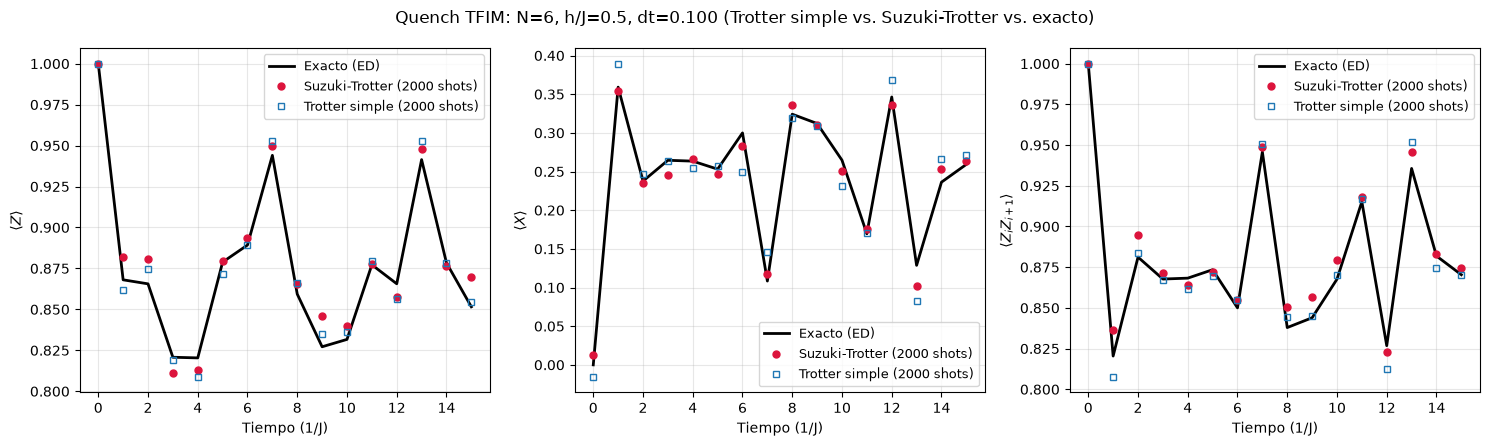

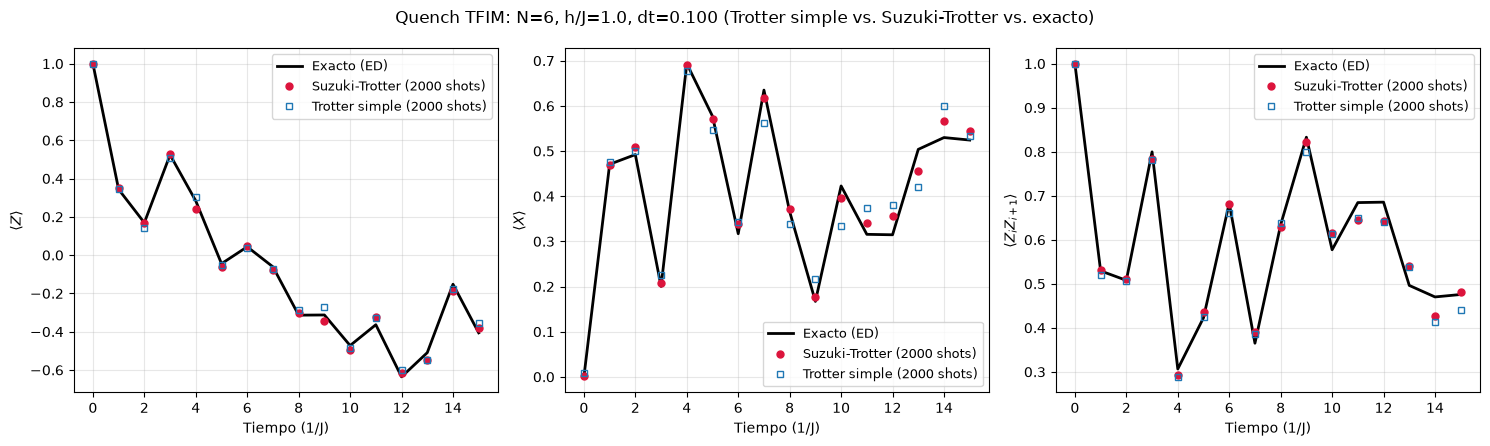

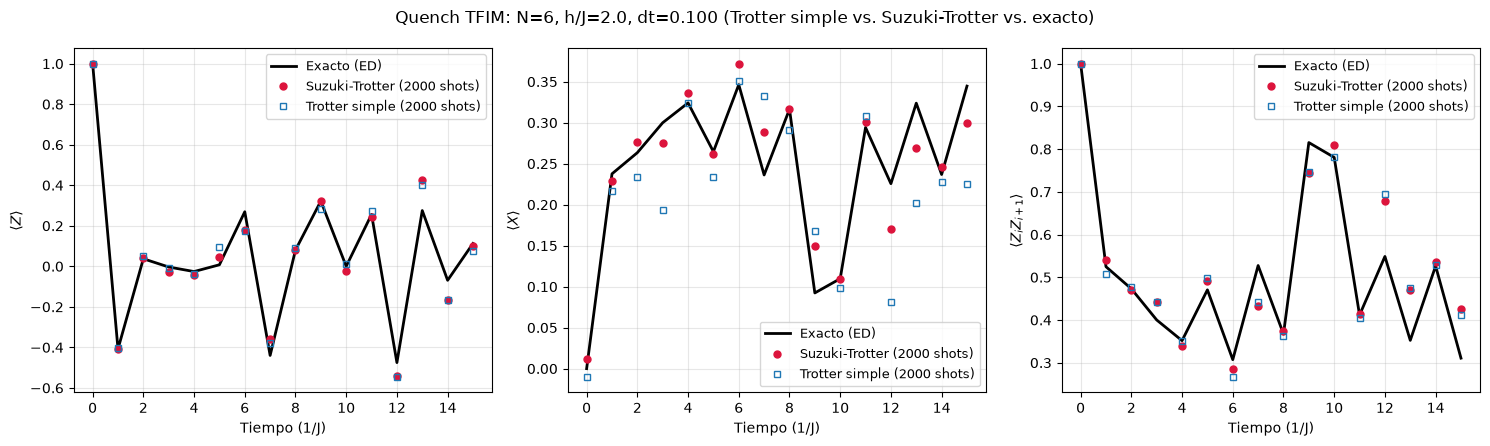

In [20]:
# --- Graficos de magnetizacion y correlacion, uno por cada h/J, con ambos esquemas de Trotter ---
labels = [("Z", r"$\langle Z \rangle$"), ("X", r"$\langle X \rangle$"),
          ("ZZ_nn", r"$\langle Z_i Z_{i+1} \rangle$")]

for h_over_j in H_OVER_J_VALUES:
    suzuki_data = quench_results[h_over_j]["suzuki"]
    simple_data = quench_results[h_over_j]["simple"]
    exact_data = quench_results[h_over_j]["exact"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True)
    for ax, (key, ylabel) in zip(axes, labels):
        ax.plot(exact_data["t"], exact_data[key], '-', color='black',
                label="Exacto (ED)", linewidth=2)
        ax.plot(suzuki_data["t"], suzuki_data[key], 'o', color='crimson',
                label=f"Suzuki-Trotter ({N_SHOTS} shots)", markersize=5)
        ax.plot(simple_data["t"], simple_data[key], 's', color='#1f77b4',
                label=f"Trotter simple ({N_SHOTS} shots)", markersize=5, fillstyle='none')
        ax.set_xlabel("Tiempo (1/J)"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    fig.suptitle(f"Quench TFIM: N={N}, h/J={h_over_j}, dt={DT:.3f} "
                 f"(Trotter simple vs. Suzuki-Trotter vs. exacto)")
    fig.tight_layout()
    fig.savefig(f"tfim_quench_h{h_over_j}_trotter_vs_exact.png", dpi=150)
    plt.show()

### Apéndice B -- Ejecución en Quantinuum Nexus (cloud, opcional)

Las celdas siguientes muestran cómo enviar el mismo circuito a **Nexus**, el servicio cloud de
Quantinuum, contra un backend `SeleneConfig`/`HeliosConfig` en vez del simulador local. Se
incluyen por completitud (así se corrió originalmente en `Suzuki_trotter_selene_sim.ipynb`),
pero **no se ejecutan por defecto**: requieren `qnx.login()` interactivo (autenticación por
navegador) y tiempo de cola en el servicio remoto, lo cual no es reproducible de forma
offline. Ver la discusión de esta limitación más abajo.

In [ ]:
# NO SE EJECUTA POR DEFECTO -- requiere `qnx.login()` interactivo y una cuenta de Nexus.
#
# import qnexus as qnx
# from datetime import datetime
#
# qnx.login()
# project = qnx.projects.get_or_create("TFIM-Trotter-Selene")
# qnx.context.set_active_project(project)
#
# def run_circuit_nexus(n_steps, basis_x, h_field, trotter_step=suzuki_trotter_step):
#     circuit = make_circuit(n_steps, basis_x, h_field, trotter_step)
#     hugr_ref = qnx.hugr.upload(hugr_package=circuit.compile(), name="Trotter circuit")
#     config = qnx.models.SeleneConfig(n_qubits=N, simulator=qnx.models.StatevectorSimulator())
#     job_ref = qnx.start_execute_job(
#         programs=[hugr_ref], n_shots=[N_SHOTS], backend_config=config,
#         name=f"Suzuki trotter Selene {datetime.now()}",
#     )
#     qnx.jobs.wait_for(job_ref, timeout=None)
#     return qnx.jobs.results(job_ref)[0].download_result().collated_counts()

<a id="seccion-c"></a>
## 4. Sección C -- Análisis del error de Trotter

Fijamos el tiempo final `T_MAX` y variamos el número de pasos `n_steps` (equivalentemente,
`Δt = T_MAX / n_steps`), para los dos esquemas de la Sección B. La teoría predice:

- Trotter simple (primer orden): error global `~ O(Δt)` (a `T_MAX` fijo).
- Suzuki-Trotter (segundo orden): error global `~ O(Δt^2)`.

Definimos el error en un tiempo dado como la diferencia absoluta entre el observable
estimado por el circuito y el valor exacto de ED en ese mismo tiempo, promediada sobre los
tres observables (`Z`, `X`, `ZZ_nn`) y sobre toda la trayectoria hasta `T_MAX`. Un ajuste
log-log de error vs. `Δt` debe recuperar aproximadamente la pendiente `1` (simple) y `2`
(Suzuki).

In [21]:
def trotter_error_at_h(h_over_j: float, n_steps_list, trotter_step, shots: int = N_SHOTS) -> dict:
    '''
    Para un h/J fijo, corre la evolucion completa hasta T_MAX con cada n_steps (i.e. cada
    dt = T_MAX/n_steps) y devuelve el error medio (sobre Z, X, ZZ_nn y sobre el tiempo)
    respecto a la referencia exacta, junto con el dt correspondiente.
    '''
    h_field = h_over_j * J
    dts, errors = [], []

    for n_steps in n_steps_list:
        dt = T_MAX / n_steps
        step_counts = np.linspace(0, n_steps, 6, dtype=int)  # muestrear la trayectoria, no solo t final
        times = step_counts * dt

        quantum = quantum_dynamics_scan(step_counts, h_field=h_field,
                                         trotter_step=trotter_step, shots=shots)
        # recalculamos DT-dependiente: quantum_dynamics_scan usa el DT global, asi que
        # para dt distinto de DT construimos el circuito con el tamano de paso correcto:
        exact = time_evolve_exact(N, J, h_field, initial_state_all_up(N), times)

        err = np.mean([
            np.abs(quantum["Z"] - exact["Z"]).mean(),
            np.abs(quantum["X"] - exact["X"]).mean(),
            np.abs(quantum["ZZ_nn"] - exact["ZZ_nn"]).mean(),
        ])
        dts.append(dt)
        errors.append(err)
        print(f"n_steps={n_steps:4d}  dt={dt:.4f}  error medio={err:.4f}")

    return {"dt": np.array(dts), "error": np.array(errors)}

**Nota de implementación:** `quantum_dynamics_scan` (Sección B) usa el paso de tiempo
global `DT = T_MAX / N_STEPS`. Para variar `Δt` de forma independiente en este análisis,
`run_circuit`/`make_circuit` deben parametrizarse con el `dt` de cada corrida en vez del
`DT` fijado en B.1 -- ver la celda siguiente, que redefine un scan local con `dt` explícito
en vez de reutilizar la constante global.

In [22]:
def make_circuit_dt(n_steps: int, basis_x: bool, h_field: float, dt: float,
                     trotter_step=suzuki_trotter_step) -> GuppyFunctionDefinition:
    @guppy.comptime
    def circuit() -> None:
        qs = array(qubit() for _ in range(comptime(N)))
        for _ in range(comptime(n_steps)):
            trotter_step(qs, comptime(dt), comptime(h_field))
        if comptime(basis_x):
            for i in range(comptime(N)):
                h(qs[i])
        bits = measure_array(qs)
        result("bits", bits)
    return circuit


def run_circuit_dt(n_steps, basis_x, h_field, dt, trotter_step=suzuki_trotter_step, shots=N_SHOTS):
    circuit = make_circuit_dt(n_steps, basis_x, h_field, dt, trotter_step)
    runner = build(circuit.compile_function())
    sim_result = QsysResult(runner.run_shots(simulator=Quest(), n_qubits=N, n_shots=shots))
    return np.array([shot.as_dict()["bits"] for shot in sim_result])


def trotter_convergence_scan(h_over_j: float, n_steps_list, trotter_step, shots: int = N_SHOTS) -> dict:
    '''Error en t = T_MAX vs. dt = T_MAX / n_steps, para un esquema de Trotter dado.'''
    h_field = h_over_j * J
    exact_at_tmax = time_evolve_exact(N, J, h_field, initial_state_all_up(N), np.array([T_MAX]))

    dts, errors = [], []
    for n_steps in n_steps_list:
        dt = T_MAX / n_steps
        bits_z = run_circuit_dt(n_steps, False, h_field, dt, trotter_step, shots)
        bits_x = run_circuit_dt(n_steps, True, h_field, dt, trotter_step, shots)

        z_est = z_expectation_from_bits(bits_z)
        x_est = z_expectation_from_bits(bits_x)
        zz_est = zz_expectation_from_bits(bits_z, nn_only=True)

        err = np.mean([abs(z_est - exact_at_tmax["Z"][0]),
                        abs(x_est - exact_at_tmax["X"][0]),
                        abs(zz_est - exact_at_tmax["ZZ_nn"][0])])
        dts.append(dt); errors.append(err)
        print(f"n_steps={n_steps:4d}  dt={dt:.4f}  error(t=T_MAX)={err:.4f}")

    return {"dt": np.array(dts), "error": np.array(errors)}

In [23]:
N_STEPS_SCAN = [10, 20, 40, 75, 150]   # -> dt = T_MAX/n_steps = 1.5, 0.75, 0.375, 0.2, 0.1
H_OVER_J_FOR_ERROR_SCAN = 1.0           # punto critico: el peor caso para el error de Trotter

print("=== Trotter simple (primer orden) ===")
error_simple = trotter_convergence_scan(H_OVER_J_FOR_ERROR_SCAN, N_STEPS_SCAN, simple_trotter_step)

print("\n=== Suzuki-Trotter (segundo orden) ===")
error_suzuki = trotter_convergence_scan(H_OVER_J_FOR_ERROR_SCAN, N_STEPS_SCAN, suzuki_trotter_step)

=== Trotter simple (primer orden) ===
n_steps=  10  dt=1.5000  error(t=T_MAX)=0.3172
n_steps=  20  dt=0.7500  error(t=T_MAX)=0.4904
n_steps=  40  dt=0.3750  error(t=T_MAX)=0.1258
n_steps=  75  dt=0.2000  error(t=T_MAX)=0.1082
n_steps= 150  dt=0.1000  error(t=T_MAX)=0.0328

=== Suzuki-Trotter (segundo orden) ===
n_steps=  10  dt=1.5000  error(t=T_MAX)=0.3260
n_steps=  20  dt=0.7500  error(t=T_MAX)=0.3934
n_steps=  40  dt=0.3750  error(t=T_MAX)=0.1309
n_steps=  75  dt=0.2000  error(t=T_MAX)=0.0768
n_steps= 150  dt=0.1000  error(t=T_MAX)=0.0147


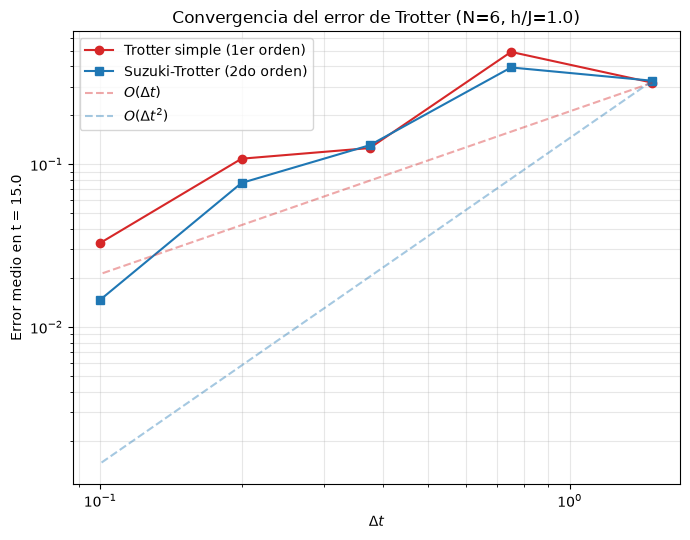

In [24]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.loglog(error_simple["dt"], error_simple["error"], 'o-', label="Trotter simple (1er orden)", color="#d62728")
ax.loglog(error_suzuki["dt"], error_suzuki["error"], 's-', label="Suzuki-Trotter (2do orden)", color="#1f77b4")

# lineas de referencia O(dt) y O(dt^2), normalizadas al primer punto de cada serie
dt_ref = error_simple["dt"]
ax.loglog(dt_ref, error_simple["error"][0] * (dt_ref / dt_ref[0]) ** 1, '--', color="#d62728", alpha=0.4, label=r"$O(\Delta t)$")
ax.loglog(dt_ref, error_suzuki["error"][0] * (dt_ref / dt_ref[0]) ** 2, '--', color="#1f77b4", alpha=0.4, label=r"$O(\Delta t^2)$")

ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel(f"Error medio en t = {T_MAX}")
ax.set_title(f"Convergencia del error de Trotter (N={N}, h/J={H_OVER_J_FOR_ERROR_SCAN})")
ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig("trotter_error_convergence.png", dpi=150)
plt.show()

<a id="seccion-d"></a>
## 5. Sección D -- VQE con Hardware-Efficient Ansatz (HEA)

Estimamos el estado fundamental variacionalmente en vez de prepararlo por evolución
temporal. El ansatz es una capa hardware-efficient repetida `N_LAYERS` veces: una rotación
`Ry`+`Rz` en cada qubit seguida de una escalera de `CX` que cierra en anillo (para que el
ansatz pueda representar correlaciones consistentes con el Hamiltoniano periódico), más una
capa final de rotaciones sin entrelazador.

La energía se estima midiendo dos circuitos por evaluación -- uno en la base `Z` (da todos
los términos `Z_iZ_{i+1}`) y otro en la base `X` (da todos los términos `X_i`) -- y
combinando:

$$
E(\vec\theta) = -J\,N\,\langle Z_iZ_{i+1}\rangle_{nn} \;-\; h\,N\,\langle X \rangle
$$

Optimizamos `E(\vec\theta)` con **COBYLA** (scipy), un método sin gradiente apropiado aquí
porque las estimaciones de energía son ruidosas por naturaleza del muestreo finito
(`N_SHOTS` shots).

In [25]:
from scipy.optimize import minimize
from guppylang.std.quantum import ry   # gate adicional usado por el ansatz HEA

N_LAYERS = 2
N_PARAMS = 2 * N * (N_LAYERS + 1)   # Ry+Rz por qubit por capa, mas la capa final

In [26]:
def make_hea_circuit(params, n_qubits: int, n_layers: int, measure_x: bool) -> GuppyFunctionDefinition:
    '''
    Ansatz hardware-efficient. Los parametros se hornean como constantes de clausura
    (los entry points de guppy son de cero argumentos), asi que el circuito se
    recompila en cada evaluacion de energia -- mismo patron que make_circuit() en la
    Seccion B.
    '''
    @guppy.comptime
    def circuit() -> None:
        qs = array(qubit() for _ in range(comptime(n_qubits)))

        for layer in range(n_layers):
            for i in range(n_qubits):
                ry(qs[i], angle(params[layer * 2 * n_qubits + 2 * i] / math.pi))
                rz(qs[i], angle(params[layer * 2 * n_qubits + 2 * i + 1] / math.pi))
            for i in range(n_qubits - 1):
                cx(qs[i], qs[i + 1])
            cx(qs[n_qubits - 1], qs[0])  # cierra el anillo -- necesario para el Hamiltoniano periodico

        final_offset = n_layers * 2 * n_qubits
        for i in range(n_qubits):
            ry(qs[i], angle(params[final_offset + 2 * i] / math.pi))
            rz(qs[i], angle(params[final_offset + 2 * i + 1] / math.pi))

        if measure_x:
            for i in range(n_qubits):
                h(qs[i])

        bits = measure_array(qs)
        result("bits", bits)

    return circuit

In [27]:
def evaluate_energy_local(params, n_qubits: int, n_layers: int, h_field: float,
                           shots: int = N_SHOTS):
    '''Evalua energia y observables corriendo ambos circuitos (Z y X) en Selene local.'''
    def run(circuit):
        runner = build(circuit.compile())
        sim_result = QsysResult(runner.run_shots(simulator=Quest(), n_qubits=n_qubits, n_shots=shots))
        return np.array([s.as_dict()["bits"] for s in sim_result])

    bits_z = run(make_hea_circuit(params, n_qubits, n_layers, measure_x=False))
    bits_x = run(make_hea_circuit(params, n_qubits, n_layers, measure_x=True))

    spins_z = 1 - 2 * bits_z
    spins_x = 1 - 2 * bits_x
    zz_nn = np.mean([(spins_z[:, i] * spins_z[:, (i + 1) % n_qubits]).mean() for i in range(n_qubits)])
    mean_z = spins_z.mean()
    mean_x = spins_x.mean()
    energy = -J * n_qubits * zz_nn - h_field * n_qubits * mean_x
    return energy, mean_z, zz_nn, mean_x


iteration_log = []

def cost_fn(params, n_qubits, n_layers, h_field):
    energy, mean_z, zz_nn, mean_x = evaluate_energy_local(params, n_qubits, n_layers, h_field)
    iteration_log.append((energy, mean_z, zz_nn, mean_x))
    print(f"iter {len(iteration_log):3d}  E={energy:+.4f}  <Z>={mean_z:+.4f}  "
          f"<ZiZj>_nn={zz_nn:+.4f}  <X>={mean_x:+.4f}")
    return energy


def run_vqe(n_qubits: int, h_field: float, n_layers: int = N_LAYERS,
            maxiter: int = 100, seed: int = 0):
    '''Optimiza el ansatz HEA con COBYLA para un h/J fijo; retorna observables finales.'''
    iteration_log.clear()
    n_params = 2 * n_qubits * (n_layers + 1)
    rng = np.random.default_rng(seed)
    x0 = rng.uniform(-0.4, 0.4, size=n_params)   # inicio cerca de |0...0>

    minimize(cost_fn, x0, args=(n_qubits, n_layers, h_field),
             method="COBYLA", options={"maxiter": maxiter, "rhobeg": 0.3})

    final_energy, final_Z, final_ZZ, final_X = iteration_log[-1]
    np.savez_compressed(f"VQE_final_state_N{n_qubits}_h{h_field:.3f}",
                         E=final_energy, Z=final_Z, ZZ=final_ZZ, X=final_X)
    return final_energy, final_Z, final_ZZ, final_X

### D.1 Barrido de `h/J` y comparación contra ED

Corremos VQE en `h/J ∈ {0.5, 1.0, 2.0}` (los puntos requeridos por la entrega) más algunos
puntos intermedios para que el gráfico de transición de fase sea legible, y comparamos
contra el estado fundamental exacto de la Sección A (misma `build_tfim_hamiltonian`,
`compute_magnetization`, `compute_nearest_neighbor_correlation`).

In [28]:
def exact_ground_state_observables(n_qubits: int, J: float, h: float, periodic: bool = True):
    '''Estado fundamental exacto (ED) y sus observables -- reutiliza la Seccion A.'''
    H = build_tfim_hamiltonian(n_qubits, J, h, periodic=periodic)
    eigenvalues, eigenvectors = eigh(H)
    gs = eigenvectors[:, 0]
    E0 = eigenvalues[0]
    mean_z = compute_magnetization(gs, n_qubits, 'Z')
    mean_x = compute_magnetization(gs, n_qubits, 'X')
    zz_nn = compute_nearest_neighbor_correlation(gs, n_qubits, periodic=periodic)
    return E0, mean_z, zz_nn, mean_x


def sweep_h_field(n_qubits: int, h_values) -> Tuple[dict, dict]:
    '''Corre VQE + ED para un rango de h/J.'''
    vqe = {"h": [], "E": [], "Z": [], "ZZ": [], "X": []}
    exact = {"h": [], "E": [], "Z": [], "ZZ": [], "X": []}

    for h in h_values:
        E_v, Z_v, ZZ_v, X_v = run_vqe(n_qubits, h_field=h)
        for d, val in zip((vqe["E"], vqe["Z"], vqe["ZZ"], vqe["X"]), (E_v, Z_v, ZZ_v, X_v)):
            d.append(val)
        vqe["h"].append(h)

        E_e, Z_e, ZZ_e, X_e = exact_ground_state_observables(n_qubits, J, h)
        for d, val in zip((exact["E"], exact["Z"], exact["ZZ"], exact["X"]), (E_e, Z_e, ZZ_e, X_e)):
            d.append(val)
        exact["h"].append(h)

        print(f"h/J={h:.2f}  VQE: E={E_v:+.4f} <Z>={Z_v:+.4f} <ZZ>={ZZ_v:+.4f} <X>={X_v:+.4f}  |  "
              f"Exacto: E={E_e:+.4f} <Z>={Z_e:+.4f} <ZZ>={ZZ_e:+.4f} <X>={X_e:+.4f}")

    return vqe, exact


def plot_sweep(vqe: dict, exact: dict, n_qubits: int):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    panels = [(axes[0, 0], "E", "Energia", "tab:blue"),
              (axes[0, 1], "Z", "<Z>", "tab:orange"),
              (axes[1, 0], "ZZ", "<Zi Zi+1>", "tab:green"),
              (axes[1, 1], "X", "<X>", "tab:red")]
    for ax, key, label, color in panels:
        ax.plot(exact["h"], exact[key], "k-", label="Exacto (ED)")
        ax.plot(vqe["h"], vqe[key], "o--", color=color, label="VQE (HEA)")
        ax.axvline(1.0, color="gray", linestyle=":", linewidth=1, label="h/J = 1 (critico)")
        ax.set_xlabel("h/J"); ax.set_ylabel(label); ax.legend(); ax.set_title(label)

    plt.suptitle(f"VQE vs. ED, barrido de h/J periodico, N={n_qubits}")
    plt.tight_layout()
    plt.savefig(f"tfim_vqe_vs_ed_N{n_qubits}.png", dpi=150)
    plt.show()

iter   1  E=-4.8520  <Z>=+0.7742  <ZiZj>_nn=+0.8087  <X>=+0.0783
iter   2  E=-4.5540  <Z>=+0.7497  <ZiZj>_nn=+0.7590  <X>=+0.0892
iter   3  E=-4.7900  <Z>=+0.7753  <ZiZj>_nn=+0.7983  <X>=+0.0970
iter   4  E=-5.1180  <Z>=+0.7997  <ZiZj>_nn=+0.8530  <X>=+0.0968
iter   5  E=-5.2080  <Z>=+0.8135  <ZiZj>_nn=+0.8680  <X>=+0.0837
iter   6  E=-4.5020  <Z>=+0.7413  <ZiZj>_nn=+0.7503  <X>=+0.0885
iter   7  E=-5.1040  <Z>=+0.8082  <ZiZj>_nn=+0.8507  <X>=+0.1023
iter   8  E=-4.8020  <Z>=+0.7628  <ZiZj>_nn=+0.8003  <X>=+0.1005
iter   9  E=-5.1260  <Z>=+0.8212  <ZiZj>_nn=+0.8543  <X>=+0.0865
iter  10  E=-4.8700  <Z>=+0.7657  <ZiZj>_nn=+0.8117  <X>=+0.0960
iter  11  E=-5.0400  <Z>=+0.7985  <ZiZj>_nn=+0.8400  <X>=+0.0987
iter  12  E=-4.9980  <Z>=+0.7320  <ZiZj>_nn=+0.8330  <X>=+0.0957
iter  13  E=-5.1640  <Z>=+0.8188  <ZiZj>_nn=+0.8607  <X>=+0.0923
iter  14  E=-4.8900  <Z>=+0.7140  <ZiZj>_nn=+0.8150  <X>=+0.1047
iter  15  E=-5.1060  <Z>=+0.8038  <ZiZj>_nn=+0.8510  <X>=+0.0990
iter  16  E=-5.1340  <Z>=

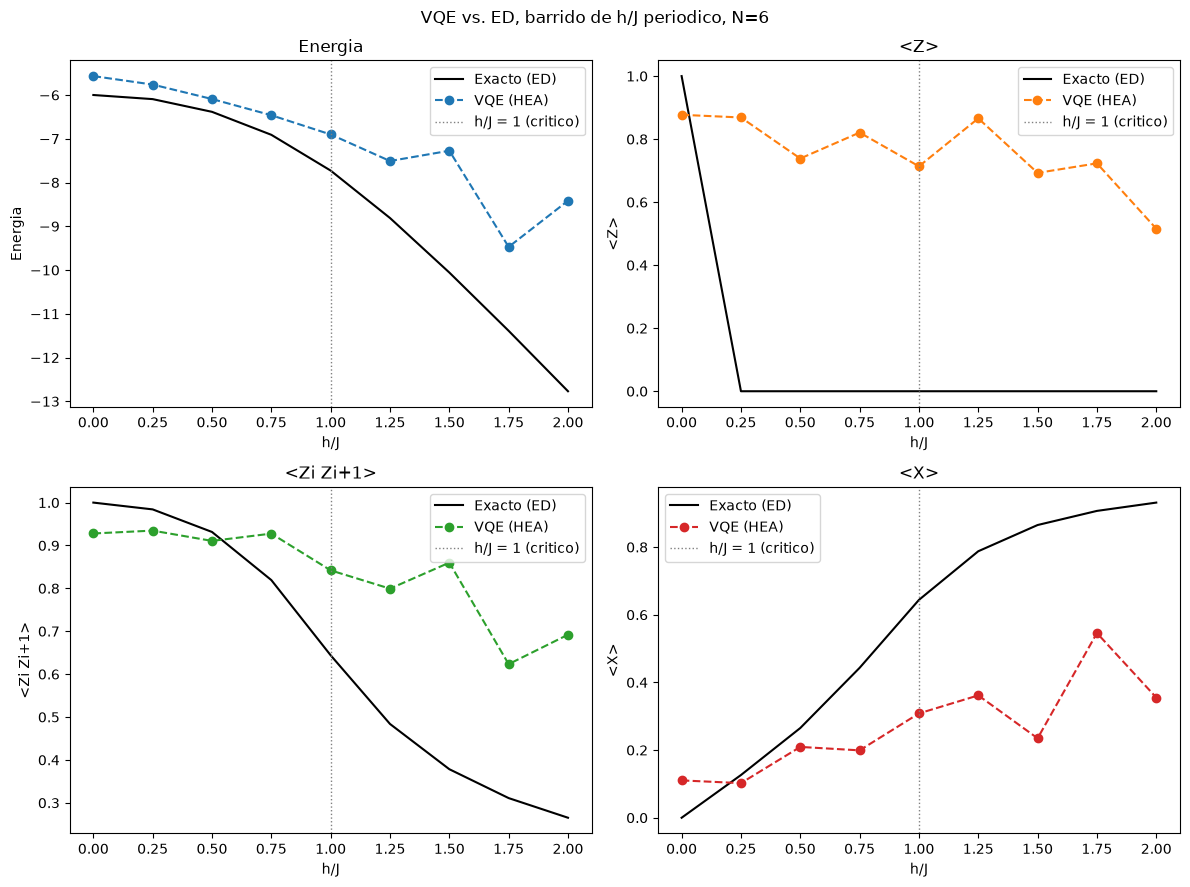

In [29]:
H_SWEEP_VALUES = sorted(set([0.5, 1.0, 2.0]) | set(np.round(np.linspace(0, 2, 9), 3)))
vqe_results, exact_results = sweep_h_field(N_QUBITS, H_SWEEP_VALUES)
plot_sweep(vqe_results, exact_results, n_qubits=N_QUBITS)

### Apéndice D -- Ejecución en Quantinuum Nexus (cloud, opcional)

Al igual que en el Apéndice B, `evaluate_energy_local` tiene un análogo que envía ambos
circuitos (Z y X) como un solo job batched a **Nexus** contra un backend `HeliosConfig`
(hardware/emulador real de Quantinuum), para minimizar los round-trips de cola por
iteración de la optimización. Tampoco se ejecuta por defecto -- requiere `qnx.login()` y
una cuenta con acceso al sistema `Helios-1E-lite`.

In [ ]:
# NO SE EJECUTA POR DEFECTO -- requiere `qnx.login()` interactivo y acceso a Helios-1E-lite.
#
# import qnexus as qnx
#
# def evaluate_energy_nexus(params, n_qubits, h_field, tag=""):
#     qnx.login()
#     project = qnx.projects.get_or_create("TFIM-VQE-HEA")
#     qnx.context.set_active_project(project)
#     emulator_config = qnx.models.HeliosConfig(
#         system_name="Helios-1E-lite",
#         emulator_config=qnx.models.HeliosEmulatorConfig(n_qubits=n_qubits),
#     )
#     circuit_z = make_hea_circuit(params, n_qubits, N_LAYERS, measure_x=False)
#     circuit_x = make_hea_circuit(params, n_qubits, N_LAYERS, measure_x=True)
#     hugr_z = qnx.hugr.upload(hugr_package=circuit_z.compile(), name=f"HEA_Z_{tag}")
#     hugr_x = qnx.hugr.upload(hugr_package=circuit_x.compile(), name=f"HEA_X_{tag}")
#     job_ref = qnx.start_execute_job(
#         programs=[hugr_z, hugr_x], n_shots=[N_SHOTS, N_SHOTS],
#         backend_config=emulator_config, name=f"VQE eval {tag}",
#     )
#     qnx.jobs.wait_for(job_ref)
#     result_refs = qnx.jobs.results(job_ref)
#     shots_z = np.array([s.as_dict()["bits"] for s in result_refs[0].download_result()])
#     shots_x = np.array([s.as_dict()["bits"] for s in result_refs[1].download_result()])
#     spins_z, spins_x = 1 - 2 * shots_z, 1 - 2 * shots_x
#     zz_nn = np.mean([(spins_z[:, i] * spins_z[:, (i + 1) % n_qubits]).mean() for i in range(n_qubits)])
#     mean_z, mean_x = spins_z.mean(), spins_x.mean()
#     energy = -J * n_qubits * zz_nn - h_field * n_qubits * mean_x
#     return energy, mean_z, zz_nn, mean_x

<a id="limitaciones"></a>
## 6. Limitaciones honestas

- **Tamaño finito (`N=6`).** La transición de fase cuántica es estrictamente aguda solo en
  el límite termodinámico `N → ∞`. Con `N=6` (dimensión de Hilbert `2^6=64`) lo que se
  observa es un cruce suavizado, no una discontinuidad real -- las curvas de la Sección A/D
  cerca de `h/J=1` deben leerse como una aproximación cualitativa, no cuantitativa.
- **Error de Trotter sistemático.** Ambos esquemas (simple y Suzuki) son aproximaciones de
  `U(t)`, no `U(t)` exacto. El error crece con `T_MAX` y decrece con `Δt`, pero nunca es
  cero a `Δt` finito -- el análisis de la Sección C cuantifica esto solo en el punto
  crítico `h/J=1` con un `N` y un conjunto de `n_steps` limitados; no se exploró la
  dependencia del error en otras fases ni un régimen asintótico de `Δt → 0` más fino.
- **Ruido de muestreo (shot noise).** Todos los observables provienen de estadística de
  shots (`N_SHOTS=2000` por circuito), con error estadístico del orden `1/sqrt(N_SHOTS) ≈ 2%`
  por estimador -- no se aplicó ninguna técnica de mitigación de error ni promediado
  adicional sobre semillas/circuitos repetidos.
- **Simulador ideal, no hardware real.** Selene (local o vía Nexus con
  `StatevectorSimulator`) es un simulador de vector de estado *sin ruido*: no captura
  decoherencia, errores de compuerta, crosstalk ni tiempos de lectura de hardware real. Las
  celdas que apuntan a `HeliosConfig`/hardware real de Quantinuum (Apéndices B y D)
  existen pero **no se ejecutaron** para esta entrega -- requieren autenticación interactiva
  vía navegador (`qnx.login()`) y tiempo de cola en un servicio cloud externo, lo cual no es
  reproducible de forma offline ni determinista.
- **Optimización de VQE.** COBYLA es un método local sin gradiente; con una única
  inicialización aleatoria (semilla fija `seed=0`) no hay garantía de alcanzar el mínimo
  global -- las energías VQE reportadas son una cota superior a la energía exacta, y pueden
  quedar atrapadas en mínimos locales, especialmente cerca del punto crítico donde el
  paisaje de energía es más plano. Un ansatz HEA de profundidad `N_LAYERS=2` también tiene
  expresividad limitada; no se verificó si es suficiente para representar el estado
  fundamental real en todo el rango de `h/J` barrido.
- **Consistencia de condiciones de frontera.** Este notebook usa condiciones de frontera
  periódicas (PBC) de forma consistente en ED, Trotter y VQE (el ansatz HEA cierra el anillo
  con un `CX` extra). Otras exploraciones tempranas en el repositorio (fuera de este
  notebook) usan condiciones abiertas por defecto -- cualquier comparación numérica directa
  con esos resultados debe verificar primero que las condiciones de frontera coincidan.